# DataCrunch Equity Market Neutral - Louis Vadet
Prediction of expected returns for the 3000 most liquid US equities.

In [ ]:
%pip install crunch-cli --upgrade --quiet --progress-bar off
!crunch setup-notebook datacrunch-2 qYqimv4aVLVnfLSUsBwLSsOf


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
crunch-cli, version 11.1.0
delete /Users/louisvadet/Desktop/best submission/.crunchdao
you appear to have never submitted code before
data/moons_split.json: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/210/moons_split.json (11088 bytes)
data/y.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/210/y.reduced.parquet (7849920 bytes)
data/X.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/210/X.reduced.parquet (717782846 bytes)
                                                                                
---
Success! Your environment has been correctly setup.
Next recommended actions:
1. Load the Crunch Toolings: `crunch_tools = crunc

## Setup

In [2]:
import os 
import joblib
import pandas as pd
import crunch
import numpy as np
import sklearn  # == 1.7.2
from sklearn.linear_model import Ridge, LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
plt.style.use('seaborn-v0_8-whitegrid')

In [4]:
crunch_tools = crunch.load_notebook()

loaded inline runner with module: <module '__main__'>

cli version: 11.1.0
available ram: 16.00 gb
available cpu: 8 core
----


## Explore the data

In [5]:
def get_feature_columns(X: pd.DataFrame):
    return [column for column in X.columns if column.startswith("Feature_")]

# This function just return a list of colomns in the dataframe which names start with "Feature_", 

In [6]:
# Load the data
X_train, y_train, X_test = crunch_tools.load_data()

data/moons_split.json: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/210/moons_split.json (11088 bytes)
data/moons_split.json: already exists, file length match
data/y.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/210/y.reduced.parquet (7849920 bytes)
data/y.reduced.parquet: already exists, file length match
data/X.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/210/X.reduced.parquet (717782846 bytes)
data/X.reduced.parquet: already exists, file length match


In [ ]:
X_train.head()
# No leakage risk: the id changes every moon

,id,moon,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,...,Feature_1141,Feature_1142,Feature_1143,Feature_1144,Feature_1145,Feature_1146,Feature_1147,Feature_1148,Feature_1149,Feature_1150
0,1309,1,0.67,0.67,0.67,0.67,0.67,0.67,0.67,0.17,...,0.50,0.67,0.00,0.00,0.00,0.00,0.33,0.50,0.50,0.67
1,621,1,0.83,0.83,0.83,0.83,0.83,0.83,0.83,1.00,...,0.50,0.67,0.17,0.17,0.17,0.17,0.50,0.67,0.67,0.67
2,1855,1,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.33,...,0.33,0.50,0.83,0.83,0.83,0.83,1.00,0.33,0.33,0.17
3,650,1,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,...,0.83,0.83,0.50,0.50,0.50,0.50,0.33,0.67,0.50,0.67
4,759,1,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.67,...,0.67,0.83,0.17,0.17,0.17,0.17,0.33,0.50,0.50,0.33


In [8]:
feature_cols = get_feature_columns(X_train)

# Confirm features are bounded in [0, 1]
print(f"Global min: {X_train[feature_cols].min().min():.2f}")
print(f"Global max: {X_train[feature_cols].max().max():.2f}")

Global min: 0.00
Global max: 1.00


In [9]:
y_train.head()

,id,moon,target
0,1309,1,0.0
1,621,1,0.0
2,1855,1,0.0
3,650,1,0.0
4,759,1,0.0


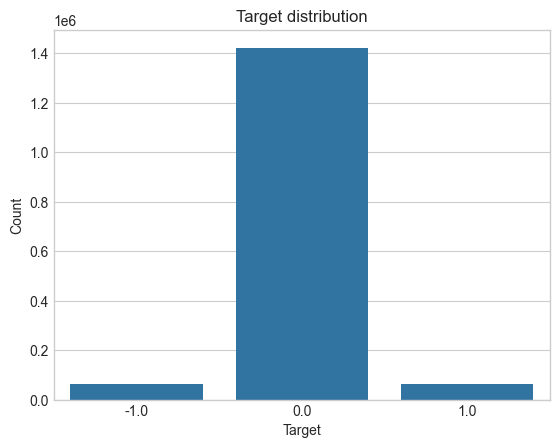

In [10]:
sns.countplot(x="target", data=y_train, order=[-1.0, 0.0, 1.0])
plt.title("Target distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

In [11]:
# Check for missing values
cols_with_missing = [col for col in X_train.columns if X_train[col].isnull().any()]
print(f"{len(cols_with_missing)} columns with missing values — {'imputation needed' if cols_with_missing else 'no imputation needed'}")

0 columns with missing values — no imputation needed


In [12]:
X_train.dtypes.value_counts()
# Only int and float — no categorical variables, no encoding needed

float32    1150
int32         2
Name: count, dtype: int64

## Model: train and infer functions

The target is ternary: most stocks stay at **0**, a few have strong moves at **+1** or **-1**.  
A single regressor struggles with this structure, so I use a two-stage approach:

1. **LogisticRegression** : classifies each stock as "mover" (±1) or "non-mover" (0)
2. **Ridge regression** : trained only on movers, predicts the direction (+1 or -1)

Final prediction: `proba_extreme × direction`, clipped to [-1, 1]

Feature selection is done once via **Spearman correlation** between each feature and the target, across all moons.  
Spearman is preferred over Pearson here because the target is ternary (-1, 0, 1) — not normally distributed.  
It handles ties by assigning average ranks, which makes it robust to this kind of discrete target.  
The top 500 features (out of 1150) by absolute correlation are kept and saved to disk, so they can be reused in `infer()` without recomputing.



In [ ]:
def train(X_train: pd.DataFrame, y_train: pd.DataFrame, model_directory_path: str) -> None:
    feature_columns = get_feature_columns(X_train)
    data = X_train[["moon", "id"] + feature_columns].merge(y_train[["moon", "id", "target"]], on=["moon", "id"])
    top_features_path = os.path.join(model_directory_path, "top_features.joblib")

    if os.path.exists(top_features_path):
        top_features = joblib.load(top_features_path)
    else:
        # Spearman correlation — rapide et efficace pour données financières
        spearman_scores = data[feature_columns].corrwith(data["target"], method="spearman").abs()
        top_features = spearman_scores.nlargest(500).index.tolist()
        joblib.dump(top_features, top_features_path)

    # Étape 1 : classifier non-zero vs zero
    data["is_extreme"] = (data["target"] != 0).astype(int)
    clf = LogisticRegression(C=0.5, max_iter=1000, n_jobs=-1)
    clf.fit(data[top_features], data["is_extreme"])

    # Étape 2 : Ridge sur les non-zero uniquement pour prédire +1 ou -1
    data_extreme = data[data["target"] != 0]
    reg = Ridge(alpha=100)
    reg.fit(data_extreme[top_features], data_extreme["target"])

    joblib.dump(clf, os.path.join(model_directory_path, "clf.joblib"))
    joblib.dump(reg, os.path.join(model_directory_path, "reg.joblib"))
    


In [ ]:
def infer(X_test: pd.DataFrame, model_directory_path: str) -> pd.DataFrame:
    prediction = X_test[["id", "moon"]].copy()
    clf = joblib.load(os.path.join(model_directory_path, "clf.joblib"))
    reg = joblib.load(os.path.join(model_directory_path, "reg.joblib"))
    top_features = joblib.load(os.path.join(model_directory_path, "top_features.joblib"))

    # Probabilité d'être un stock extrême (+1 ou -1)
    proba_extreme = clf.predict_proba(X_test[top_features])[:, 1]

    # Direction prédite par Ridge (+1 ou -1)
    direction = reg.predict(X_test[top_features])

    # Prédiction finale : proba_extreme * direction
    # → proche de 0 si le stock est probablement médian
    # → proche de ±1 si le stock est probablement extrême
    prediction["prediction"] = proba_extreme * direction
    prediction["prediction"] = prediction["prediction"].clip(-1, 1)

    return prediction

## Local testing


In [15]:
crunch_tools.test(force_first_train=True,train_frequency=0)

20:28:27 note: detection is based on the previous execution of the cell; if you have already corrected the issue(s), please restart the kernel and run all cells again
20:28:27 
20:28:27 started
20:28:27 running local test
20:28:27 internet access isn't restricted, no check will be done
20:28:27 
20:28:27 looping moon=773 train=True (1/9)
20:28:27 executing - command=train


data/moons_split.json: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/210/moons_split.json (11088 bytes)
data/moons_split.json: already exists, file length match
data/y.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/210/y.reduced.parquet (7849920 bytes)
data/y.reduced.parquet: already exists, file length match
data/X.reduced.parquet: download from https:crunchdao--competition--production.s3-accelerate.amazonaws.com/data-releases/210/X.reduced.parquet (717782846 bytes)
data/X.reduced.parquet: already exists, file length match


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


: 

: 

## Results

In [ ]:
prediction = pd.read_parquet("prediction/prediction.parquet") 
prediction

,id,moon,prediction
0,1621514,773,-0.001797
1,1620399,773,0.004115
2,1622126,773,0.015822
3,1621963,773,0.015250
4,1620703,773,0.009877
...,...,...,...
16983,1636502,781,-0.018838
16984,1636666,781,0.006930
16985,1636232,781,-0.004583
16986,1636831,781,-0.005518


## Local scoring

In [ ]:
# Load the targets
y_test = pd.read_parquet("data/y.reduced.parquet",filters=[("moon", "in", prediction["moon"].unique())])
y_test 

,id,moon,target
0,1621514,773,0.0
1,1620399,773,0.0
2,1622126,773,0.0
3,1621963,773,-1.0
4,1620703,773,0.0
...,...,...,...
16983,1636502,781,0.0
16984,1636666,781,0.0
16985,1636232,781,0.0
16986,1636831,781,0.0


In [ ]:
# Define the scoring function (la corrélation de Pearson utilisée par CrunchDAO)
def score(group: pd.DataFrame):
    return group["prediction"].corr(group["target"], method="pearson")




# Merge the prediction with the target y (with moon and id)
merged = y_test.merge(prediction,on=["moon", "id"])

# Compute the pearson for each moon
pearson_values = merged.groupby("moon").apply(score, include_groups=False).fillna(0)  # map constants to zero

print(pearson_values) # voir si certains moons sont très différents des autres
print(pearson_values.mean())

moon
773    0.055254
774    0.002990
775    0.018809
776    0.057223
777    0.036901
778   -0.013745
779   -0.040399
780   -0.038433
781   -0.003259
dtype: float64
0.008371121493659602


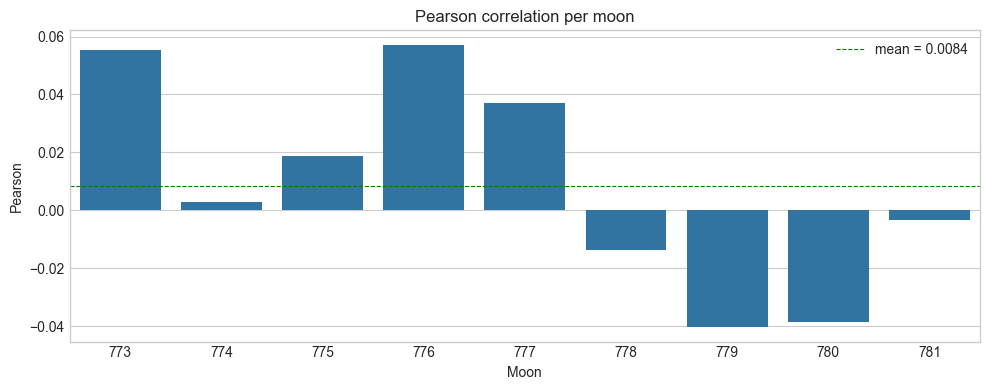

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=pearson_values.index, y=pearson_values.values, ax=ax)
ax.axhline(pearson_values.mean(), color="green", linewidth=0.8, linestyle="--", label=f"mean = {pearson_values.mean():.4f}")
ax.set_title("Pearson correlation per moon")
ax.set_xlabel("Moon")
ax.set_ylabel("Pearson")
ax.legend()
plt.tight_layout()
plt.show()
